In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

from minisom import MiniSom

In [10]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print("Normalized Data Shape:", X_scaled.shape)

Normalized Data Shape: (150, 4)


In [12]:
som = MiniSom(
    x=7,
    y=7,
    input_len=4,
    sigma=1.0,
    learning_rate=0.5
)

In [13]:
som.random_weights_init(X_scaled)

print("Training SOM...")

som.train_random(X_scaled, 100)

print("Training Completed")

Training SOM...
Training Completed


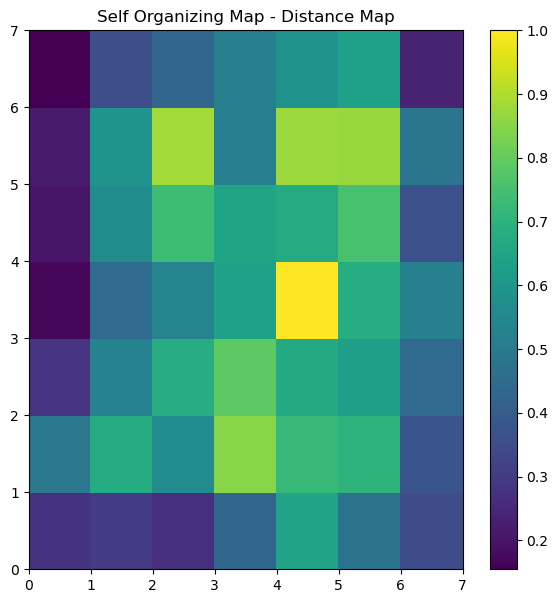

In [14]:
plt.figure(figsize=(7,7))

plt.pcolor(som.distance_map())
plt.colorbar()

plt.title("Self Organizing Map - Distance Map")

plt.show()

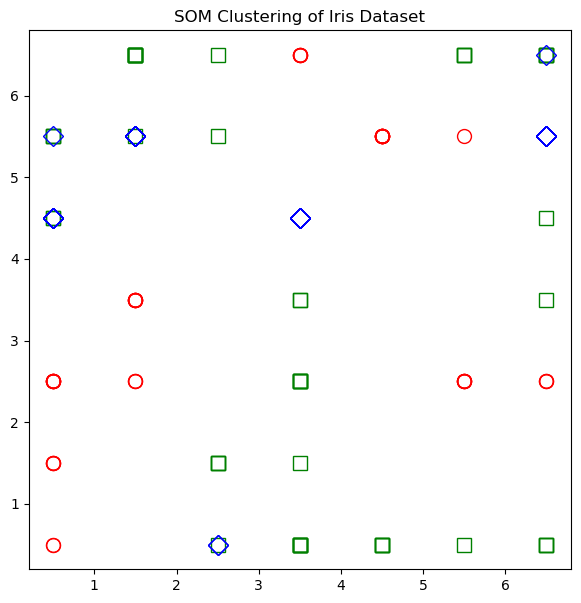

In [15]:
plt.figure(figsize=(7,7))

markers = ['o','s','D']
colors = ['r','g','b']

for i, x in enumerate(X_scaled):
    
    w = som.winner(x)
    
    plt.plot(
        w[0] + 0.5,
        w[1] + 0.5,
        markers[y[i]],
        markerfacecolor='None',
        markeredgecolor=colors[y[i]],
        markersize=10
    )

plt.title("SOM Clustering of Iris Dataset")
plt.show()

🔴 **Red Circles (o)** → *Setosa*
🟢 **Green Squares (s)** → *Versicolor*
🔵 **Blue Diamonds (D)** → *Virginica*